In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from integrative_post_gwas.simulate_ehr import main as do_ehr_simulation
from integrative_post_gwas.ehr_utils import plot_real_vs_generated

RESULTS_DIR = Path("../output/results")
LABELS_PATH = Path("../reference_data/penncath_hg38/penncath.csv")

%load_ext autoreload
%autoreload 2

## Data Setup and Simulation

In [2]:
df_labels = pd.read_csv(LABELS_PATH).set_index("ID")
print(f"labels: {df_labels.shape}")
display(df_labels.head())

labels: (1401, 6)


,CAD,sex,age,tg,hdl,ldl
ID,,,,,,
10002,1,1,60,NaN,NaN,NaN
10004,1,2,50,55.0,23.0,75.0
10005,1,1,55,105.0,37.0,69.0
10007,1,1,52,314.0,54.0,108.0
10008,1,1,58,161.0,40.0,94.0


## Data Simulation

As we don't have real EHR data, we are going to simulate 

In [ ]:
do_ehr_simulation(input_root=Path(".."), output_folder=Path("../reference_data/eir-transformer"))

In [3]:
df_seq_train = pd.read_csv("../reference_data/eir-transformer/df_ehr.csv", index_col=0)

In [4]:
df_seq_train.head(5)

,Sequence
ID,
10002_0,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...
10002_1,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...
10002_2,SEX_1 [VISIT_START] AGE_61 LAB_HDL_cholesterol...
10002_3,SEX_1 [VISIT_START] AGE_64 LAB_HDL_cholesterol...
10002_4,SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol...


In [5]:
print(df_seq_train.iloc[0]['Sequence'])

SEX_1 [VISIT_START] AGE_63 LAB_HDL_cholesterol_44% LAB_LDL_Cholesterol_86% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_67 LAB_HDL_cholesterol_38% LAB_LDL_Cholesterol_92% DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_71 LAB_HDL_cholesterol_46% LAB_LDL_Cholesterol_90% [VISIT_END]


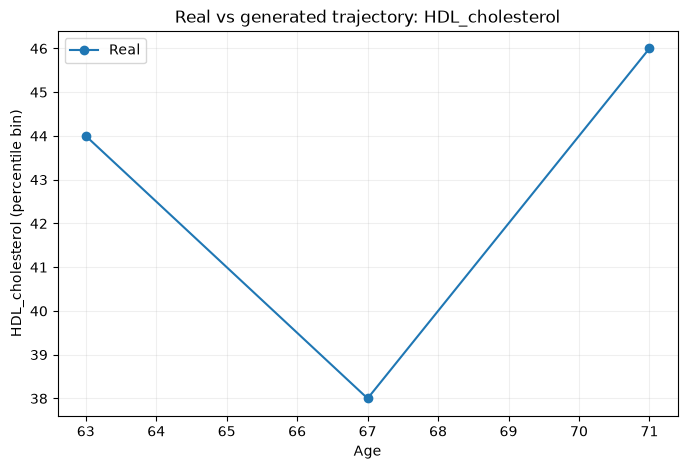

In [21]:
plot_real_vs_generated(real_seq=df_seq_train.iloc[0]['Sequence'], generated_seq=None, lab="HDL_cholesterol")

# Training

In [ ]:
!eirtrain \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence.yaml"

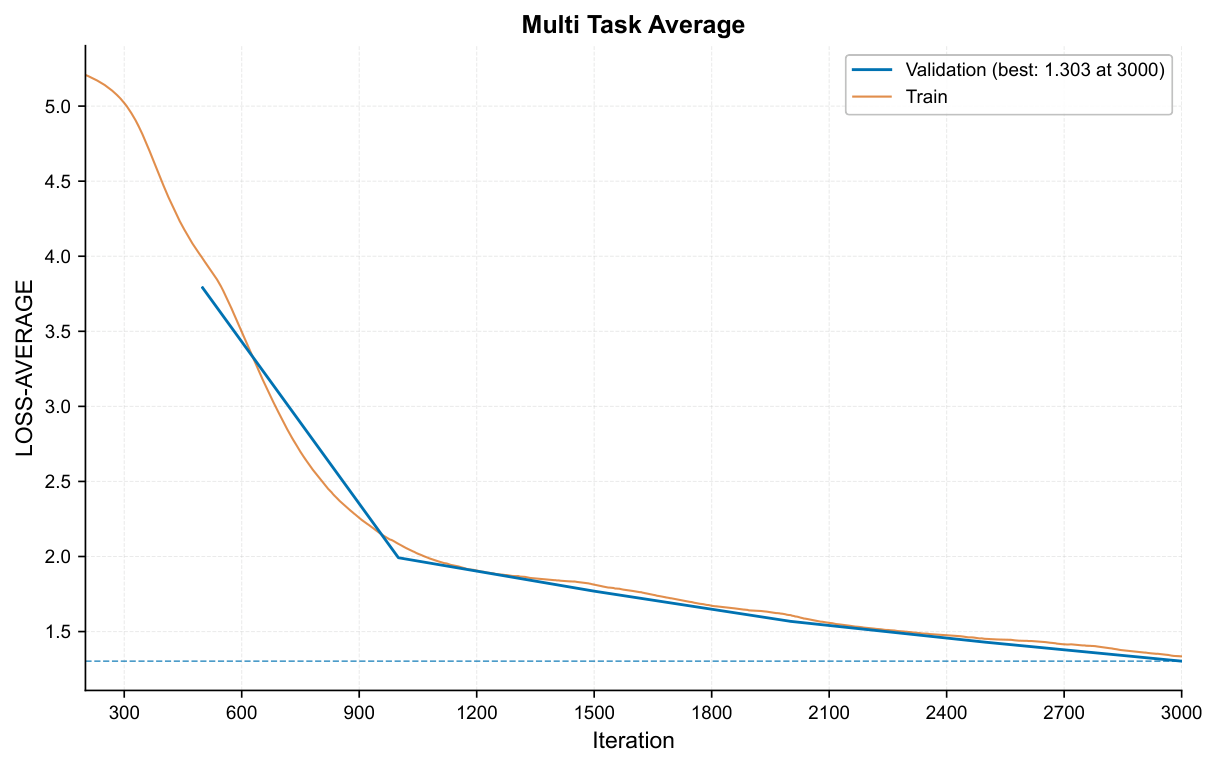

In [7]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

# Testing

In [8]:
df_test_first_visit = pd.read_csv("../reference_data/eir-transformer/df_ehr_test_first_visit.csv", index_col=["ID"])

In [9]:
test_sample_index = 0

In [10]:
df_test_first_visit.iloc[test_sample_index].Sequence

'SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_88% LAB_LDL_Cholesterol_88% DX_I25 [VISIT_END]'

In [11]:
import yaml
from pathlib import Path

def set_manual_inputs(
    prompts: str | list[str],
    config_path: str = "../configs/eir-transformer/output_sequence_test.yaml",
) -> None:
    if isinstance(prompts, str):
        prompts = [prompts]

    config_path = Path(config_path)
    with open(config_path) as handle:
        config = yaml.safe_load(handle)

    config["sampling_config"]["manual_inputs"] = [{"ehr": p} for p in prompts]

    with open(config_path, "w") as handle:
        yaml.safe_dump(config, handle, sort_keys=False, default_flow_style=False)

In [12]:
prompt = df_test_first_visit["Sequence"].iloc[test_sample_index]
current_id = df_test_first_visit.index[test_sample_index]
print(prompt)

SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_88% LAB_LDL_Cholesterol_88% DX_I25 [VISIT_END]


In [13]:
set_manual_inputs(prompts=prompt)

In [ ]:
!eirpredict \
    --global_configs "../configs/eir-transformer/globals.yaml" \
    --output_configs "../configs/eir-transformer/output_sequence_test.yaml" \
    --model_path "../runs/ehr_transformer/saved_models/ehr_transformer_checkpoint_3000_perf-average=-0.3030.pt" \
    --evaluate \
    --output_folder "../runs/ehr_transformer/test_set_predictions"

## Analyzing test performance

In [14]:
with open("../runs/ehr_transformer/test_set_predictions/results/ehr/ehr/samples/0/manual/10_generated.txt") as infile:
    generated = infile.read()

In [15]:
generated

'SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_88% LAB_LDL_Cholesterol_88% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_61 LAB_HDL_cholesterol_96% LAB_LDL_Cholesterol_78% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_64 LAB_HDL_cholesterol_100% LAB_LDL_Cholesterol_72% DX_I25 DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_66 LAB_HDL_cholesterol_100% LAB_LDL_Cholesterol_88% DX_I25 DX_E11 [VISIT_END]'

In [16]:
df_test_full = pd.read_csv("../reference_data/eir-transformer/df_ehr_test.csv", index_col=["ID"])

In [17]:
df_test_full.loc[current_id]["Sequence"]

'SEX_2 [VISIT_START] AGE_58 LAB_HDL_cholesterol_88% LAB_LDL_Cholesterol_88% DX_I25 [VISIT_END] [SEP] [VISIT_START] AGE_59 LAB_HDL_cholesterol_92% LAB_LDL_Cholesterol_90% DX_I25 DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_60 LAB_HDL_cholesterol_94% LAB_LDL_Cholesterol_86% DX_I25 DX_E11 [VISIT_END] [SEP] [VISIT_START] AGE_61 LAB_HDL_cholesterol_94% LAB_LDL_Cholesterol_88% DX_I25 DX_E11 [VISIT_END]'

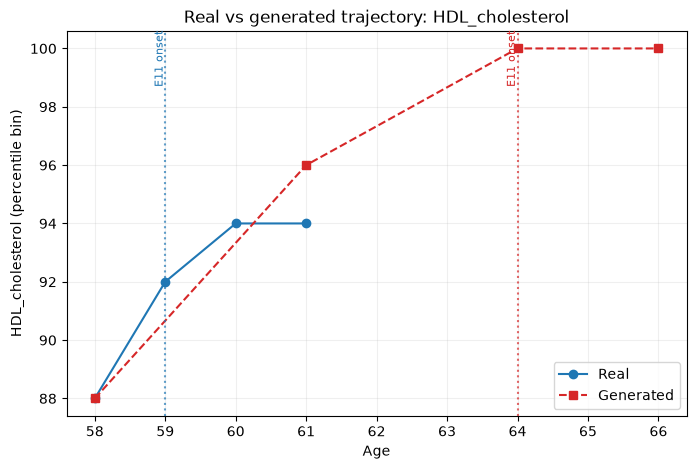

In [20]:
real_seq = df_test_full.loc[current_id]["Sequence"]
plot_real_vs_generated(real_seq=real_seq, generated_seq=generated, lab="HDL_cholesterol", disease="E11")

# Training with GRS as additional inputs

In [ ]:
def load_trait_csv(path: Path) -> pd.Series:
  df = pd.read_csv(path).set_index("ID")
  trait = path.stem
  prob1 = [c for c in df.columns if c.endswith("Ensemble Prob 1")]
  if prob1:
      s = df[prob1[0]].rename(trait)
      s.attrs["kind"] = "binary"
      return s
  ensemble = [c for c in df.columns if re.fullmatch(rf"{re.escape(trait)} Ensemble", c)]
  if not ensemble:
      raise ValueError(f"No ensemble column found in {path.name}: {list(df.columns)}")
  s = df[ensemble[0]].rename(trait)
  s.attrs["kind"] = "continuous"
  return s

In [ ]:
RESULTS_DIR

In [ ]:
series_list, kinds = [], {}
for p in sorted(RESULTS_DIR.glob("*.csv")):
  s = load_trait_csv(p)
  series_list.append(s)
  kinds[s.name] = s.attrs["kind"]

df_grs = pd.concat(series_list, axis=1)
trait_kind = pd.Series(kinds, name="kind")
print(f"preds: {df_grs.shape}  continuous={(trait_kind=='continuous').sum()}  binary={(trait_kind=='binary').sum()}")

df_grs.index = df_grs.index.astype(str)

display(df_grs.head())

In [ ]:
import pandas as pd
import numpy as np

df_seq['base_id'] = df_seq['ID'].str.split('_').str[0]

df_expanded = df_seq[['ID', 'base_id']].merge(
    df_grs, 
    left_on='base_id', 
    right_index=True, 
    how='left'
)

numeric_cols = df_expanded.select_dtypes(include=[np.number]).columns

noise_factor = 0.01 

for col in numeric_cols:
    noise = np.random.normal(0, df_expanded[col].std() * noise_factor, size=len(df_expanded))
    df_expanded[col] = df_expanded[col] + noise

df_grs_matched = df_expanded.drop(columns=['base_id']).set_index('ID')

In [ ]:
df_grs_train = df_grs_matched[df_grs_matched.index.isin(df_seq_train["ID"])]
df_grs_test = df_grs_matched[df_grs_matched.index.isin(df_seq_test["ID"])]

In [ ]:
df_grs_train.to_csv("../reference_data/eir-transformer/df_grs.csv")
df_grs_test.to_csv("../reference_data/eir-transformer/df_grs_test.csv")

In [ ]:
import yaml

all_columns = [
    "I21",                                       # Acute Myocardial Infarction prediction
    "I25",                                       # Chronic Ischemic Heart Disease prediction
    "Lipoprotein_A",                             
    "Apolipoprotein_B_BIOCH",                    
    "I20",                                       # Angina Pectoris prediction
    "I10",                                       # Essential Hypertension prediction
    "Clinical_LDL_Cholesterol",                  
    "E11",                                       # Type 2 Diabetes prediction
    "Total_Triglycerides",                       
    "Systolic_blood_pressure_automated_reading"  
]

config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [ ]:
config = {
    'input_info': {
        'input_source': '../reference_data/eir-transformer/df_grs_test.csv',
        'input_name': 'biomarker_inputs',
        'input_type': 'tabular'
    },
    'input_type_info': {
        'input_con_columns': all_columns 
    },
    'model_config': {
        'model_type': 'tabular'
    }
}

with open('../configs/eir-transformer-with-grs/input_tabular_test.yaml', 'w') as f:
    yaml.dump(config, f, sort_keys=False, default_flow_style=False)

In [ ]:
!eirtrain \
    --global_configs "../configs/eir-transformer-with-grs/globals.yaml" \
    --input_configs  "../configs/eir-transformer-with-grs/input_tabular.yaml" \
    --fusion_configs "../configs/eir-transformer/fusion.yaml" \
    --output_configs "../configs/eir-transformer-with-grs/output_sequence.yaml"

In [ ]:
df_grs_train["I25"].describe()

In [ ]:
import fitz  
from IPython.display import Image, display

doc = fitz.open("../runs/ehr_transformer-with-grs/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0) 
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))